In [60]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from functools import partial
import matplotlib.pyplot as plt
import scipy.io as io
import sys
import numpy as np
from tqdm import tqdm
import gc

global_path = "/home/ids/edabier/HSU"
# global_path = "/home/edabier/Documents/Thèse/benchmark"
sys.path.append(f"{global_path}/HyperSIGMA/HyperspectralUnmixing")
from mmengine.optim import build_optim_wrapper
from mmcv__custom import custom_layer_decay_optimizer_constructor

from src.utils import utils
from src.utils import losses
from src.utils import plots
from src.utils import extractor
from src.models import models
from src.models import foundation_models as rsfm

if torch.cuda.is_available():
    dev = "cuda:0"
    torch.set_default_device(dev)
    print(f"Using device: {dev}")
    
elif torch.backends.mps.is_available():
    dev = torch.device("mps")
    torch.set_default_device(dev)
    print(f"Using device: {dev}")
  
else:
    dev = "cpu"
    print(f"Using device: {dev}")

Using device: cuda:0


In [61]:
dataset = "jasper"
data = io.loadmat(f"datasets/{dataset}.mat")
Y_flat = torch.tensor(data["Y"], dtype=torch.float)
A_flat = torch.tensor(data["A"], dtype=torch.float)
E_init = torch.tensor(data["E"], dtype=torch.float)
B, c, N = E_init.shape[0], E_init.shape[1], Y_flat.shape[1]

Y_init = utils.oneD_to_2d(Y_flat)
H = Y_init.shape[-1]
A_init = utils.oneD_to_2d(A_flat)
# Y_init = Y_init/Y_init.max()
Y_init = Y_init.unsqueeze(0)
A_init = A_init.unsqueeze(0)

if dataset == "urban4":
    wavelengths_path = f"{global_path}/SS-HSU_benchmark/datasets/urban_wavelength.txt"
else:
    wavelengths_path = f"{global_path}/SS-HSU_benchmark/datasets/{dataset}_wavelength.txt"
with open(wavelengths_path, "r") as file:
    lines = file.readlines()
    wavelengths = [float(line.strip()) for line in lines if line.strip()]

features: torch.Size([768, 196])
tensor(4481.3462, device='cuda:0', grad_fn=<MeanBackward0>)


1.973872

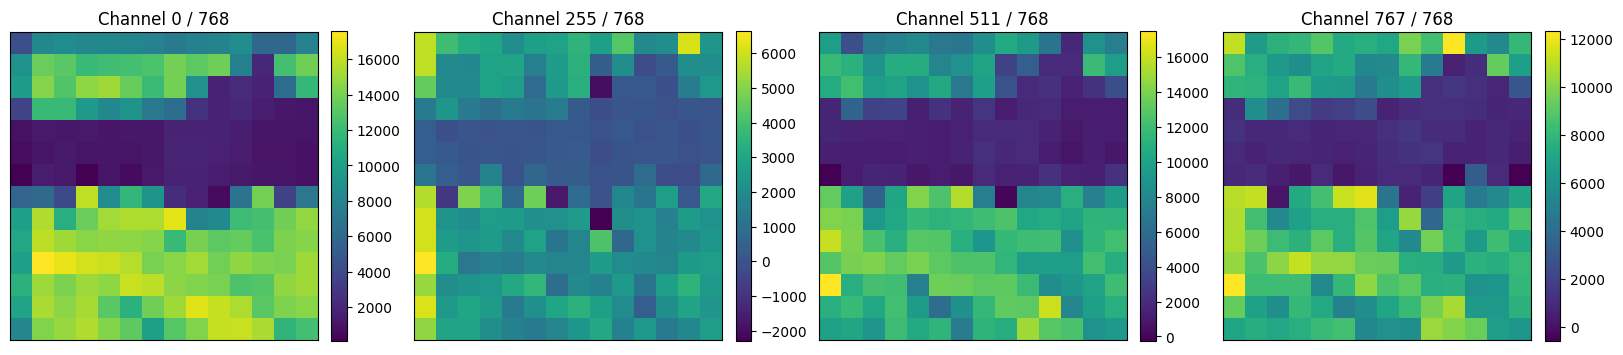

In [62]:
fm_name = "DOFA"
fm, Y_init_f, new_H = rsfm.create_fm(fm_name, Y_init, size="base", version="v1", path=global_path)

_, features = rsfm.extract_f(fm, Y_init_f, new_H, wavelengths)
D = int(features.shape[0]/1)
alpha = int(features.shape[1]**0.5)

print(f"features: {features.shape}")

plots.plot_hsi(features.reshape(D, alpha, alpha), 4)
print(features.mean())

unmixer = rsfm.Unmixing_from_features(D=D, H=min(new_H, H), alpha=alpha, B=B, c=c)
sum(p.numel() for p in unmixer.parameters() if p.requires_grad)/1e6

{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
SAD = 0.102 ± 0.01, NMSE = 0.141 ± 0.05


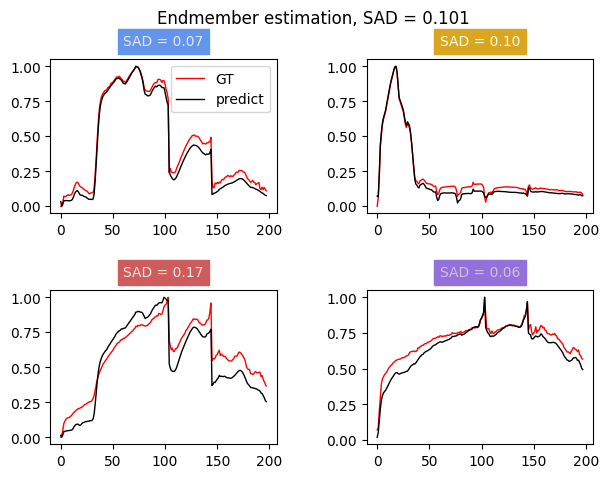

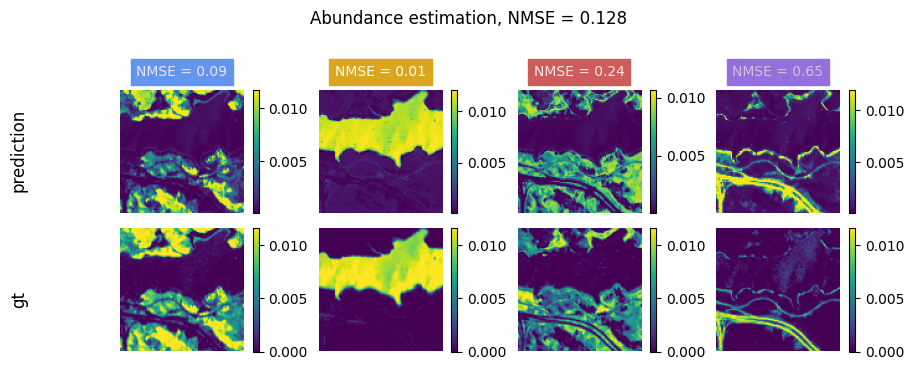

In [63]:
loader, _, _ = utils.create_dataloader(dataset, patch_size=H, dev=dev, path=global_path)
epochs, lr = 200, 0.002

optim_wrapper = dict(
    optimizer=dict(type='AdamW', lr=lr, betas=(0.9, 0.999), weight_decay=0.18),
    constructor='LayerDecayOptimizerConstructor_ViT',
    paramwise_cfg=dict(num_layers=12, layer_decay_rate=0.9))

n_xp = 3
mses, sads = [], []
mses_in, sads_in = [], []

E_hats, A_hats = torch.zeros(n_xp, B, c), torch.zeros(n_xp, c, min(new_H, H), min(new_H, H))
upsampled_features = torch.zeros(n_xp, D, min(new_H, H), min(new_H, H))

for n in range(n_xp):

    model = rsfm.Unmixing_from_features(D=D, alpha=alpha, H=min(new_H, H), B=B, c=c)
    # model = torch.compile(model)
    model.apply(model.weights_init)
    # model = models.init_decoder_weights(model, Y_init_f/Y_init_f.max(), c, is_unmixer=True, normalize=False)
    model = models.init_decoder_weights(model, Y_init/Y_init.max(), c, is_unmixer=True)

    model = model.to(dev)
    optimizer = build_optim_wrapper(model, optim_wrapper)

    for epoch in range(epochs):
        
        for Y, E, A in loader:
            optimizer.zero_grad()

            Y = utils.oneD_to_2d(Y).to(dev)
            
            Y_up, features = rsfm.extract_f(fm, Y, new_H, wavelengths)

            E_hat, A_hat, Y_hat = model(features)
            
            features_lr = utils.oneD_to_2d(features)
            features_hr = utils.oneD_to_2d(model.upsample(features))

            loss = model.loss(Y, Y_hat, A_hat, E_hat, features_hr, features_lr, W_feat=0, W_tv_feat=0)
            
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=10, norm_type=1)
            optimizer.step()

            if hasattr(model, 'decoder'):
                with torch.no_grad():
                    constraints = models.weightConstraint()
                    model.decoder.apply(constraints)

            del loss, Y, E, A, features, E_hat, A_hat, Y_hat, constraints
            torch.cuda.synchronize()
            torch.cuda.empty_cache()
            gc.collect()
        
    model.eval()

    with torch.no_grad():
        _, A, features = rsfm.extract_f(fm, Y_init, new_H, wavelengths, A_init)
        E_hat, A_hat, _ = model(features)
        up_features = model.upsample(features)
        upsampled_features[n] = utils.oneD_to_2d(up_features)
        # if xp == 1:    
        sad, _, mse = plots.compute_metrics_and_plot(E_hat, A_hat, A_init, E_init, normalize_E=True, normalize_A=True, return_results=True, plot_A=False, plot_E=False)
        sads.append(sad)
        mses.append(mse)

    E_hats[n] = E_hat
    A_hats[n] = A_hat.squeeze(0)

E_hat_m = torch.mean(E_hats, dim=0)
A_hat_m = torch.mean(A_hats, dim=0)

sad, _, mse = plots.compute_metrics_and_plot(E_hat_m, A_hat_m, A_init, E_init, normalize_E=True, normalize_A=True, return_results=True)#, plot_A=False, plot_E=False)
print(f"SAD = {format(torch.mean(torch.tensor(sads)), '.3f')} ± {format(torch.std(torch.tensor(sads)), '.2f')}, NMSE = {format(torch.mean(torch.tensor(mses)), '.3f')} ± {format(torch.std(torch.tensor(mses)), '.2f')}")
# feat_up = model.upsample(features)
# feat_up = feat_up.reshape(D, new_H, new_H)
# plots.plot_hsi(feat_up, 4)

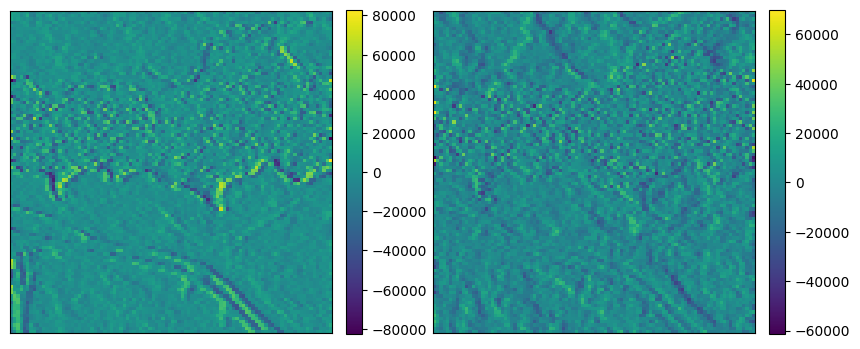

In [50]:
i = 100

up1 = upsampled_features[0][i]
up2 = upsampled_features[1][i]

fig, axs = plt.subplots(1, 2, figsize=(10,10))

im1 = axs[0].imshow(torch.gradient(up1)[1].detach().cpu())
axs[0].set_xticks([])
axs[0].set_yticks([])
plt.colorbar(im1, fraction=0.046, pad=0.04)

im2 = axs[1].imshow(torch.gradient(up2)[1].detach().cpu())
axs[1].set_xticks([])
axs[1].set_yticks([])
plt.colorbar(im2, fraction=0.046, pad=0.04)

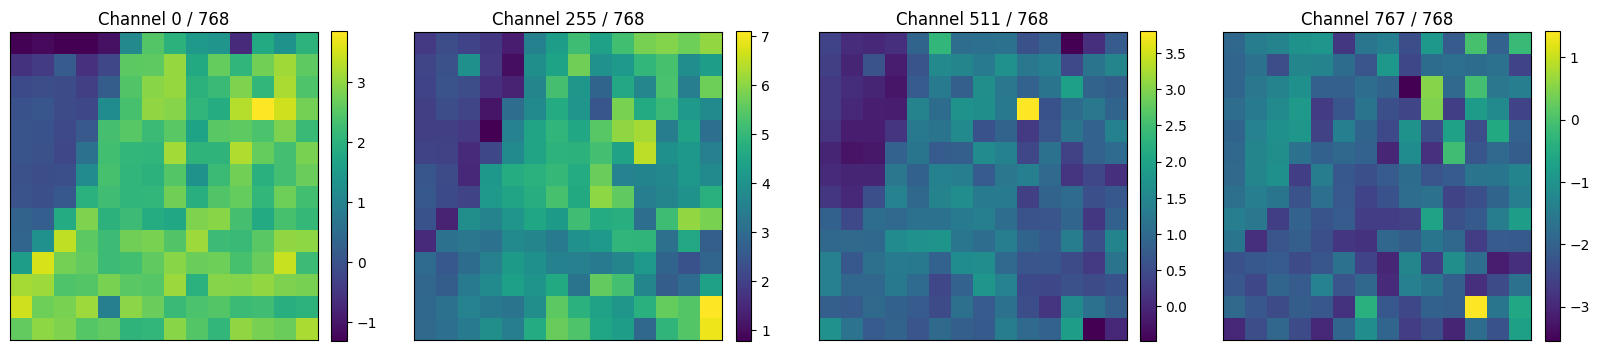

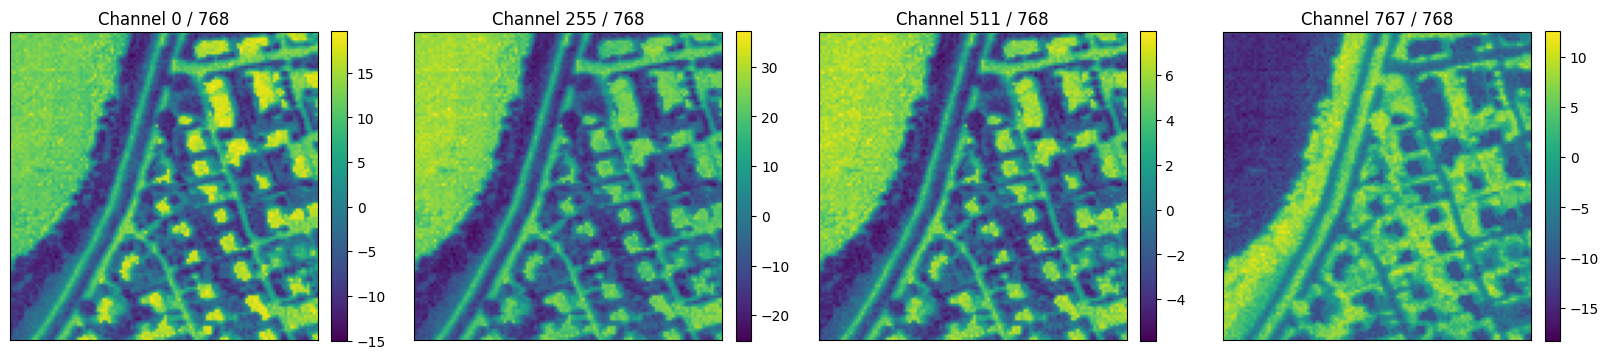

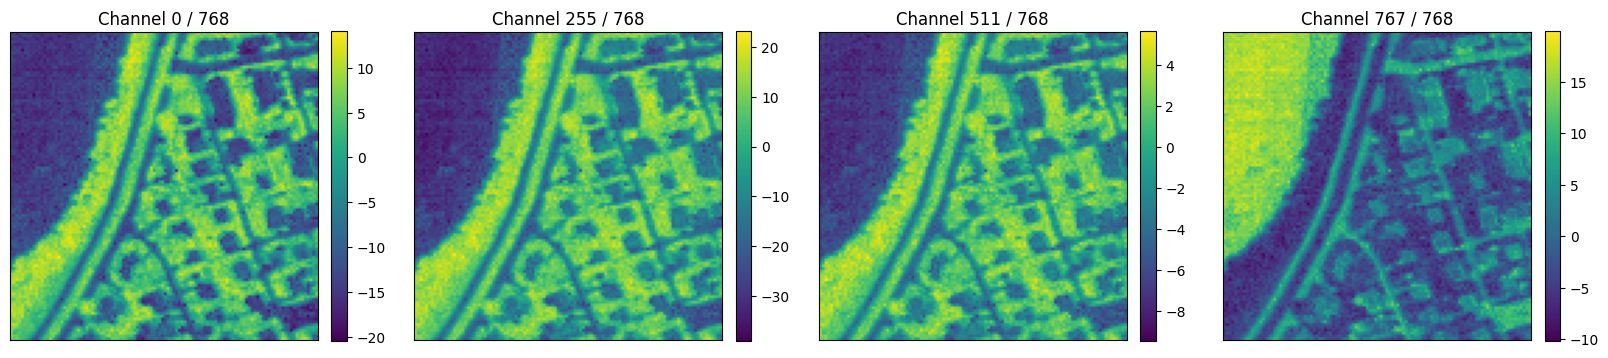

In [10]:
plots.plot_hsi(features.reshape(D, alpha, alpha), 4)
for i in range(n_xp):
    plots.plot_hsi(upsampled_features[i], 4)

In [ ]:
from code_christophe import munkres as m

def order_endmembers(E_gt, E_hat):
    if E_hat.dim() == 2:
        E_hat = E_hat.unsqueeze(0)
    if E_gt.dim() == 2:
        E_gt = E_gt.unsqueeze(0)
    
    E_hat_corr_norm = torch.zeros_like(E_hat)
    E_hat_corr = torch.zeros_like(E_hat)
    indices = torch.zeros((E_hat.size()[0],E_hat.size()[2]))
    
    for batch in range(E_gt.size()[0]):
        E0 = F.normalize(E_gt[batch,:,:],p=2.0,dim=0)
        E = F.normalize(E_hat[batch,:,:],p=2.0,dim=0)
        E0 = E0.to(torch.float32)   
        E = E.to(torch.float32)
        
        dot_products = E0.T @ E
        costmat = torch.acos(torch.clamp(dot_products, -1.0, 1.0))
        
        print(costmat.shape)
        mun = m.Munkres()
        Jperm = mun.compute(costmat.tolist())
        
        EPerm = torch.zeros(E0.shape, dtype=torch.float32)
        EPerm_norm = torch.zeros(E0.shape)
        perm_indices = torch.zeros(E0.shape[1])
        
        for c in range(E0.shape[1]):
            EPerm[:,c] = E_hat[batch,:,Jperm[c][1]]
            EPerm_norm[:,c] = E_gt[batch, :,Jperm[c][1]]
            perm_indices[c] = Jperm[c][1]
        
        E_hat_corr_norm[batch,:,:] = EPerm_norm
        E_hat_corr[batch,:,:] = EPerm
        indices[batch,:] = perm_indices
    indices = indices.type(torch.int64)

    return E_hat_corr

ref = upsampled_features[0]
up_feat = order_endmembers(ref.reshape(D, H**2).T, upsampled_features[1].reshape(D, H**2).T)
plots.plot_hsi(ref, 4)
plots.plot_hsi(up_feat, 4)

In [17]:
mse_loss = nn.MSELoss()

E_hat_2, A_hat_m_2, _ = utils.order_endmembers(E_init, E_hat_m, A_hat_m)
rmse = torch.sqrt(mse_loss(A_init, A_hat_m_2))
rmse

/home/ids/edabier/miniconda3/envs/hsu-env/lib/python3.10/site-packages/torch/utils/_device.py:103: UserWarning: Using a target size (torch.Size([3, 95, 95])) that is different to the input size (torch.Size([1, 3, 95, 95])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return func(*args, **kwargs)


tensor(0.1635, device='cuda:0')